In [ ]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float64", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"

import sphWarpCore as sph
from sphWarpCore.type_config import *

print(get_type_config()) # confirms active settings

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sample.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sample.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

# from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm
from compressibleSPH.enumTypes import *

{'scalar_t': <class 'warp._src.types.float64'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme
from compressibleSPH.caseUtils.sedov.initial import buildSedov
goalRadius = 0.8

gamma = 1.4
rho0 = 1
E0 = 1

nx = 2000
# gamma = 5/3
# leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.038

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
)


SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')

compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
from compressibleSPH.enumTypes import AdaptiveSupportScheme
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen

# display(compressibleSPHConfig.crkViscosityParams)

In [3]:
from compressibleSPH.modules import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

particles_l = sampleRegularParticles(nx, config.domain, config.targetNeighbors, jitter = 0.0)

regionA = torch.logical_and(particles_l.positions[:,0].abs() >= 0.0, particles_l.positions[:,0].abs() <= 0.1)
regionB = torch.logical_and(particles_l.positions[:,0].abs() > 0.1, particles_l.positions[:,0].abs() <= 0.9)
regionC = torch.logical_and(particles_l.positions[:,0].abs() > 0.9, particles_l.positions[:,0].abs() <= 1.9)

In [4]:
Pinitial = torch.zeros_like(particles_l.positions[:,0])
Pinitial[regionA] = 1000
Pinitial[regionB] = 0.1
Pinitial[regionC] = 100

rhoInitial = torch.ones_like(particles_l.positions[:,0])
v_initial = torch.zeros_like(particles_l.positions)

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = rhoInitial, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(v_initial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles_l.masses

In [5]:
simulationState = SimulationState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = v_initial,

    kinds = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_l.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter= particles_l.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles_l.densities),
    alpha0s = torch.ones_like(particles_l.densities),
    divergence = torch.zeros_like(particles_l.densities)
)
compressibleSystem = SimulationSystem(
    state=simulationState, 
    adjacency = None, 
    domain = config.domain)

In [6]:
config.adaptiveDt = True
dx = simulationState.masses.min()
config.dx = dx
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt)
# config.dt = 1e-4
print(f"Initial timestep: {config.dt}")

# timeLimit = 0.038
timesteps = int(timeLimit / config.dt)

print(timesteps, config.dt)

Initial timestep: 8.296481341139711e-06
4580 8.296481341139711e-06


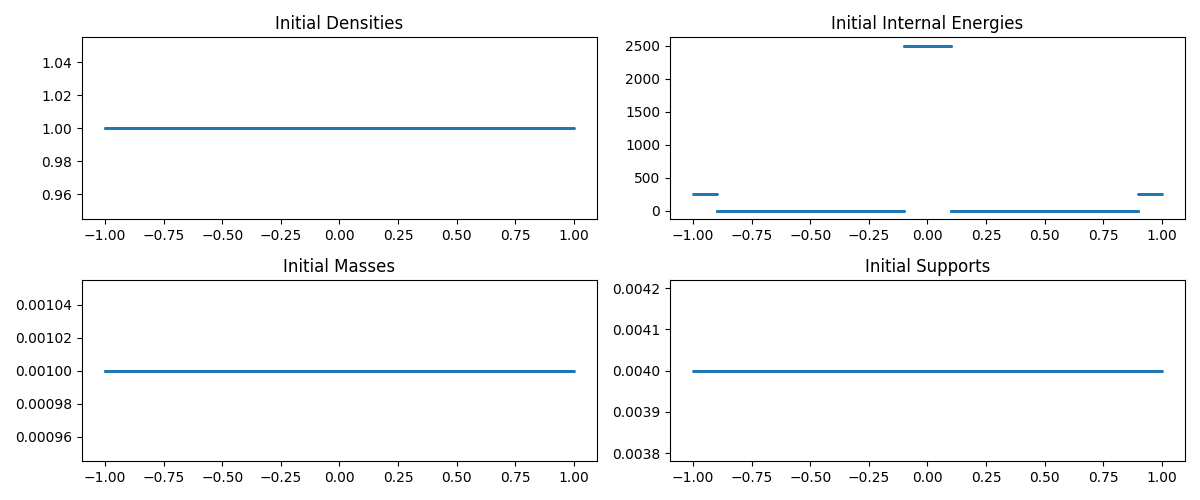

In [7]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compressibleSystem.state.positions, compressibleSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compressibleSystem.state.positions, compressibleSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compressibleSystem.state.positions, compressibleSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compressibleSystem.state.positions, compressibleSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

In [8]:
from compressibleSPH.schemes.compSPH import compSPH_step
runningState = compressibleSystem.initializeNewState()

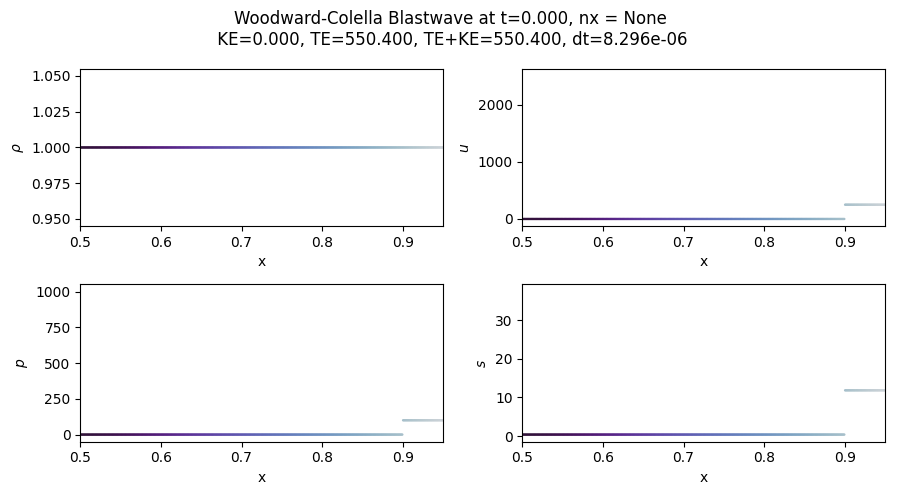

In [9]:
fig, axis = plt.subplots(2,2, figsize = (9, 5), squeeze = False)

def plotState(fig, axis, system):
    for ax in axis.flatten():
        ax.clear()
    t = system.t
    state = system.state
    s = 0.5
    c = torch.arange(state.positions.shape[0]//2).repeat(2)

    axis[0,0].scatter(state.positions.cpu(), state.densities.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[0,0].set_ylabel(r'$\rho$')
    axis[1,0].scatter(state.positions.cpu(), state.pressures.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[1,0].set_ylabel(r'$p$')
    axis[0,1].scatter(state.positions.cpu(), state.internalEnergies.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[0,1].set_ylabel(r'$u$')
    axis[1,1].scatter(state.positions.cpu(), state.soundspeeds.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[1,1].set_ylabel(r'${s}$')

    for ax in axis.flatten():
        ax.set_xlabel('x')
        # ax.set_xlim(0, 1)

    kineticEnergy = 0.5 * (torch.linalg.norm(state.velocities, dim = -1) **2 * state.masses).sum()
    thermalEnergy = (state.internalEnergies * state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy


    fig.suptitle(f'Woodward-Colella Blastwave at t={t:.3f}, nx = {config.nx}\n KE={kineticEnergy:.3f}, TE={thermalEnergy:.3f}, TE+KE={totalEnergy:.3f}, dt={config.dt:.3e}')

plotState(fig, axis, runningState)

for ax in axis.flatten():
    ax.set_xlim(0.5, 0.95)

fig.tight_layout()

In [10]:
display(compressibleSPHConfig)
compressibleSPHConfig.energyScheme = EnergyScheme.CRK
compressibleSPHConfig.diffusionParams.C_q = 1

CompSPHConfig(gamma=1.4, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CompSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, compatibleEnergy=True)

In [11]:
# config.dt = 1e-4
# timeLimit = 0.6
t_limit = timeLimit
# config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
config.dt = computeTimestep(runningState, config, compressibleSPHConfig, dt = None) * 0.5
config.cflFactor = 0.2

nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 20


config.minDt = 1e-8
trajectory = []

priorStep = None
t = 0
i = 0
tq = tqdm(total = 1000, leave = True)
while t < timeLimit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / timeLimit * 1000)
    i = i + 1

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy
    config.dt = computeTimestep(runningState, config, compressibleSPHConfig, dt = config.dt) 
    
    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{timeLimit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}, step time: {timing:.3f}ms, adaptive dt: {config.dt:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

    if torch.any(torch.isnan(runningState.state.positions)) or torch.any(torch.isnan(runningState.state.densities)) or torch.any(torch.isnan(runningState.state.internalEnergies)):
        print("NaN detected in state. Stopping simulation.")
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()
        break

    if i % 50 == 0 or i == nSteps - 1:
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()

Running with dt: 4.148240670569856e-06, which gives nSteps: 9160


  0%|          | 0/1000 [00:00<?, ?it/s]

Module compressibleSPH.modules.adaptiveSupport.wp_psi 4cacf24 load on device 'cuda:0' took 10.60 ms  (cached)
Module sphWarpCore.radiusSearch.wp_compactHash 0833861 load on device 'cuda:0' took 13.41 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 f9bb264 load on device 'cuda:0' took 6.83 ms  (cached)
Module sphWarpCore.operations.wp_density 813da29 load on device 'cuda:0' took 6.31 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 4965239 load on device 'cuda:0' took 7.56 ms  (cached)
Module compressibleSPH.modules.compSPH.accel 5a356bc load on device 'cuda:0' took 13.49 ms  (cached)
Module compressibleSPH.modules.compSPH.dudt 4a6b022 load on device 'cuda:0' took 8.96 ms  (cached)
Module sphWarpCore.operations.wp_divergence 09bbd55 load on device 'cuda:0' took 9.36 ms  (cached)
Module compressibleSPH.modules.compSPH.balance 5977ecf load on device 'cuda:0' took 6.68 ms  (cached)
NaN detected in state. Stopping simulation.


In [40]:
for stage in range(len(result.stages)):
    # print(f"Stage {stage.stageIndex}:")
    # for aux in stage.aux:
        # print(f"  Aux: {aux.__class__.__name__}")
    ap_ij = result.stages[stage].aux[1].ap_ij
    av_ij = result.stages[stage].aux[1].av_ij
    f_ij = result.stages[stage].aux[1].f_ij


    ap_ij_norm = torch.linalg.norm(ap_ij, dim = -1)
    av_ij_norm = torch.linalg.norm(av_ij, dim = -1)

    print(f'{stage}: ap_ij: min {ap_ij_norm.min():.3g}, max {ap_ij_norm.max():.3g}, mean {ap_ij_norm.mean():.3g}')
    print(f'{stage}: av_ij: min {av_ij_norm.min():.3g}, max {av_ij_norm.max():.3g}, mean {av_ij_norm.mean():.3g}')
    print(f'{stage}: f_ij: min {f_ij.min():.3g}, max {f_ij.max():.3g}, mean {f_ij.mean():.3g}')

0: ap_ij: min 0, max 6.98e+05, mean 1.16e+04
0: av_ij: min 0, max 7e+04, mean 36.4
0: f_ij: min 9.89e-05, max 1, mean 0.5
1: ap_ij: min 0, max 6.98e+05, mean 1.16e+04
1: av_ij: min 0, max 7.87e+04, mean 39
1: f_ij: min 9.89e-05, max 1, mean 0.5


In [35]:
display(compressibleSPHConfig)

CompSPHConfig(gamma=1.4, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CompSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, compatibleEnergy=True)

In [8]:
t_limit = 0.15
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54

trajectory = []
runningState = compSystem.initializeNewState()
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    elapsed_time_ms = begin.elapsed_time(end)

    runningState = result.state
    priorStep = result.stages[-1]

    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"t: {runningState.t:.4f}, KE: {kineticEnergy_:.4f}, TE: {thermalEnergy_:.4f}, TE+KE: {totalEnergy:.4f}")
        
    trajectory.append((
        i,
        runningState.t,
        elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if i % 30 == 0 or i == nSteps - 1:
        for ax in axis.flatten():
            ax.clear()
        plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        fig.canvas.draw()
        fig.canvas.flush_events()


Running with dt: 0.0003004512400366366, which gives nSteps: 499


  0%|          | 0/499 [00:00<?, ?it/s]

Module compressibleSPH.modules.compSPH.accel 7f8d199 load on device 'cuda:0' took 4.77 ms  (cached)
Module compressibleSPH.modules.compSPH.dudt 77f50b9 load on device 'cuda:0' took 5.56 ms  (cached)
Module sphWarpCore.operations.wp_divergence 8f92694 load on device 'cuda:0' took 6.34 ms  (cached)
Module compressibleSPH.modules.compSPH.balance 1babad7 load on device 'cuda:0' took 2.64 ms  (cached)


In [ ]:
from compressibleSPH.modules import *

copiedState = runningState.initializeNewState()
currentState = copiedState.state
verletScale = 1.0

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
    A = None,
    u = currentState.internalEnergies,
    P = None,
    rho = currentState.densities,
    gamma = schemeConfig.gamma,
)


velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)
velocityGradientNoCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

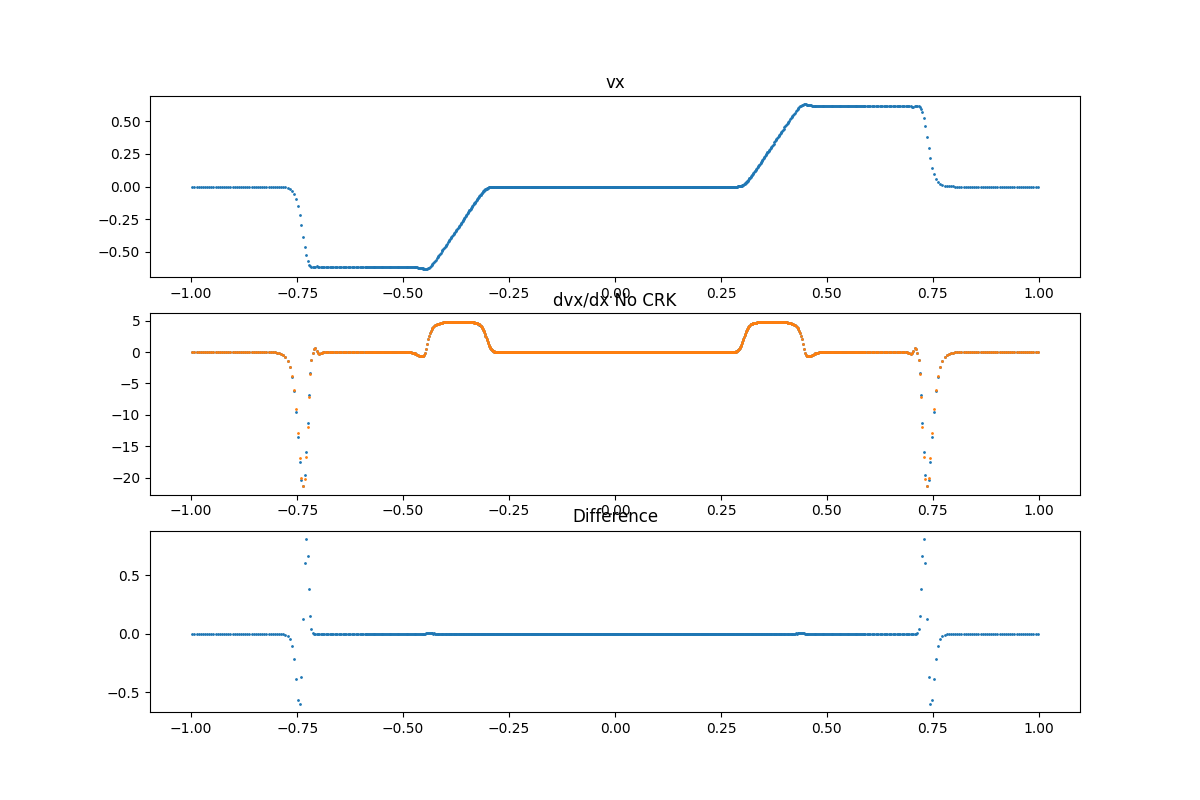

In [10]:
fig, axis = plt.subplots(3,1, figsize = (12, 8), squeeze = False)
plotToAxis1D(axis[0,0], currentState.positions, currentState.velocities[:,0], title = 'vx')

plotToAxis1D(axis[1,0], currentState.positions, velocityGradient[:,0,0], title = 'dvx/dx')
plotToAxis1D(axis[1,0], currentState.positions, velocityGradientNoCRK[:,0,0], title = 'dvx/dx No CRK')
# plotToAxis1D(axis[0,

plotToAxis1D(axis[2,0], currentState.positions, velocityGradient[:,0,0] - velocityGradientNoCRK[:,0,0], title = 'Difference')

In [11]:

@torch.jit.script
def mod(x, min : float, max : float):
    h = max - min
    return ((x + h / 2.0) - torch.floor((x + h / 2.0) / h) * h) - h / 2.0

def moduloDistance(xij, periodicity, min, max):
    return torch.stack([xij[:,i] if not periodic else mod(xij[:,i], min[i], max[i]) for i, periodic in enumerate(periodicity)], dim = -1)

def mod_distance(xi, xj, 
                 periodicity : Union[bool, torch.Tensor], 
                 minExtent : torch.Tensor, maxExtent : torch.Tensor):
    xij = xi - xj
    periodic = periodicity if isinstance(periodicity, torch.Tensor) else torch.tensor([periodicity for _ in range(xij.shape[1])]).to(xij.device)
    return moduloDistance(xij, periodic, minExtent, maxExtent)

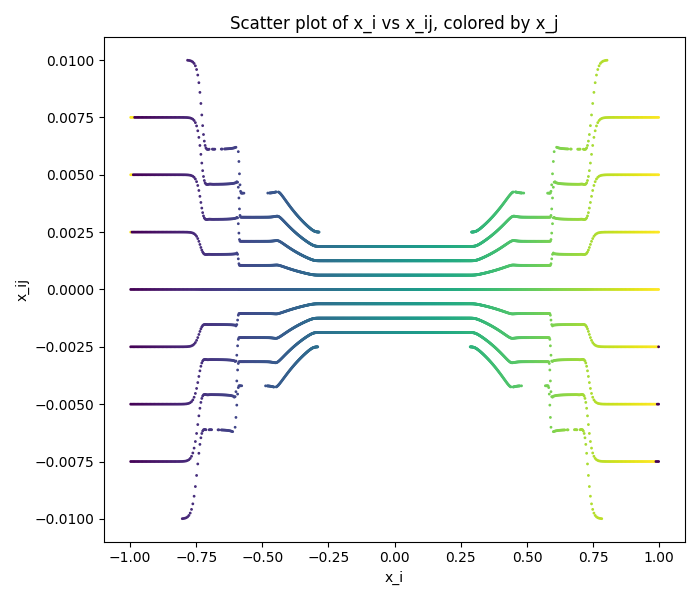

In [12]:
x_i = currentState.positions[adjacency.i]
x_j = currentState.positions[adjacency.j]


# x_ij = x_i - x_j

x_ij = mod_distance(x_i, x_j, config.domain.periodic, config.domain.min, config.domain.max) / 2


fig, axis = plt.subplots(1,1, figsize = (7, 6), squeeze = False)

axis[0,0].scatter(x_i.cpu(), x_ij.cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('x_ij')
axis[0,0].set_title('Scatter plot of x_i vs x_ij, colored by x_j')
# plt.show()
fig.tight_layout()

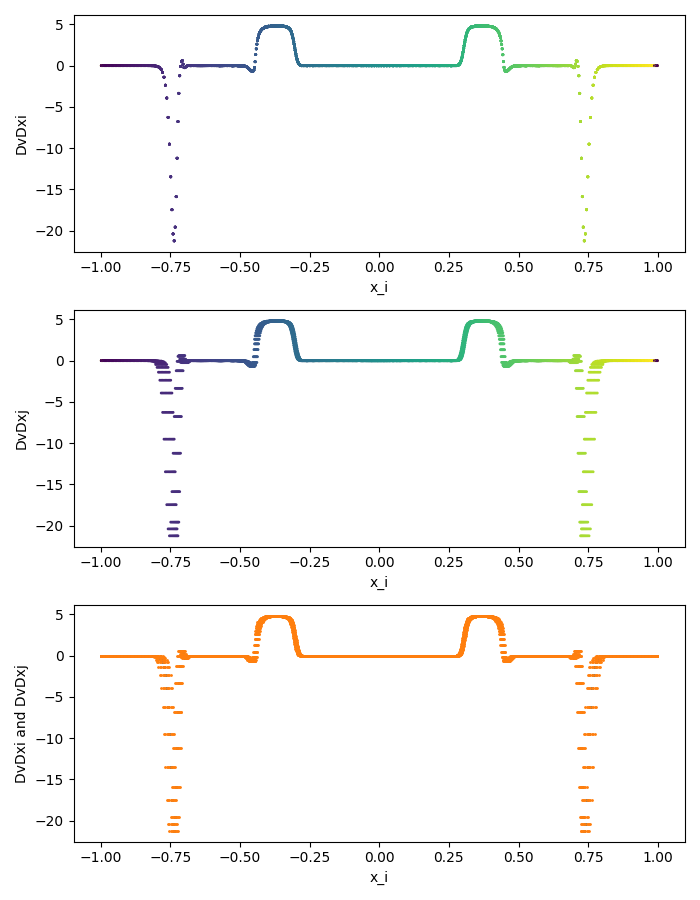

In [13]:
DvDxi = velocityGradient[adjacency.i]
DvDxj = velocityGradient[adjacency.j]

fig, axis = plt.subplots(3,1, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), DvDxi[:,0].cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('DvDxi')
# axis[0,0].set_title('Scatter plot of x_i vs DvDxi, colored by x_j')

axis[1,0].scatter(x_i.cpu(), DvDxj[:,0].cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('DvDxj')

axis[2,0].scatter(x_i.cpu(), DvDxi.cpu(), s = 1)
axis[2,0].scatter(x_i.cpu(), DvDxj.cpu(), s = 1)
axis[2,0].set_xlabel('x_i')
axis[2,0].set_ylabel('DvDxi and DvDxj')

fig.tight_layout()

In [14]:
gradi = torch.einsum('na, na -> n', torch.einsum('nab, nb -> na', DvDxi, x_ij), x_ij)
gradj = torch.einsum('na, na -> n', torch.einsum('nab, nb -> na', DvDxj, x_ij), x_ij)

print(f'gradj: min: {gradj[~torch.isnan(gradj)].min().item()}, max: {gradj[~torch.isnan(gradj)].max().item()}, mean: {gradj.nanmean().item()}, nans: {torch.isnan(gradj).sum().item()}/{gradj.numel()}, inf values: {(torch.isinf(gradj).sum().item())}')
print(f'gradi: min: {gradi[~torch.isnan(gradi)].min().item()}, max: {gradi[~torch.isnan(gradi)].max().item()}, mean: {gradi.nanmean().item()}, nans: {torch.isnan(gradi).sum().item()}/{gradi.numel()}, inf values: {(torch.isinf(gradi).sum().item())}')

gradi += 1.0e-30
gradj += 1.0e-30

def sgn(x):
    return torch.where(x >= 0, torch.tensor(1.0, device = x.device), torch.tensor(-1.0, device = x.device))

ri = gradi / (sgn(gradj) * torch.abs(gradj).clamp_min_(1.0e-30))
rj = gradj / (sgn(gradi) * torch.abs(gradi).clamp_min_(1.0e-30))

rij = torch.min(ri, rj)

print(f'rij: min: {rij[~torch.isnan(rij)].min().item()}, max: {rij[~torch.isnan(rij)].max().item()}, mean: {rij.nanmean().item()}, nans: {torch.isnan(rij).sum().item()}/{rij.numel()}, inf values: {(torch.isinf(rij).sum().item())}')

gradj: min: -0.0016563978279009461, max: 7.14220805093646e-05, mean: -5.8393193285155576e-06, nans: 0/7668, inf values: 0
gradi: min: -0.0016563978279009461, max: 7.14220805093646e-05, mean: -5.839322966494365e-06, nans: 0/7668, inf values: 0
rij: min: -334.7162780761719, max: 1.0, mean: -1.6661590337753296, nans: 0/7668, inf values: 0


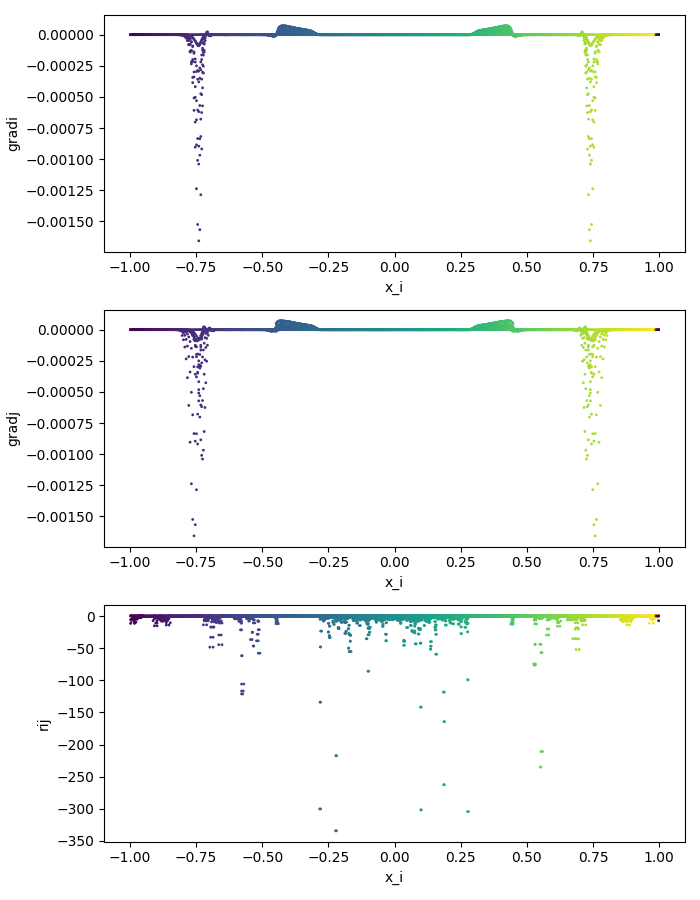

In [15]:
fig, axis = plt.subplots(3,1, figsize = (7, 9), squeeze = False)

axis[0,0].scatter(x_i.cpu(), gradi.cpu(), s = 1, c = x_j.cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('gradi')

axis[1,0].scatter(x_i.cpu(), gradj.cpu(), s = 1, c = x_j.cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('gradj')

axis[2,0].scatter(x_i.cpu(), rij.cpu(), s = 1, c = x_j.cpu())
axis[2,0].set_xlabel('x_i')
axis[2,0].set_ylabel('rij')

fig.tight_layout()


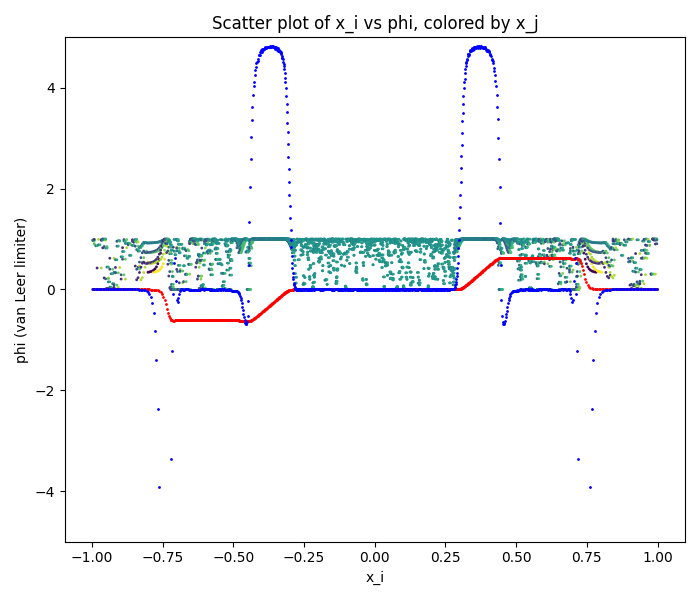

In [16]:
def vanLeer(r):
    # if r <= 0.0
        # return 0.0
    vL = 2.0 / (1.0 + r)
    return torch.where(r > 0, r * vL**2, torch.tensor(0.0, device = r.device))

phi = vanLeer(rij)

fig, axis = plt.subplots(1,1, figsize = (7, 6), squeeze = False)
axis[0,0].scatter(x_i[adjacency.i!=adjacency.j].cpu(), phi[adjacency.i!=adjacency.j].cpu(), s = 1, c = x_ij[adjacency.i!=adjacency.j].cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('phi (van Leer limiter)')
axis[0,0].set_title('Scatter plot of x_i vs phi, colored by x_j')

axis[0,0].scatter(currentState.positions.cpu(), currentState.velocities.cpu(), s = 1, c = 'red', label = 'Particle velocities')
axis[0,0].scatter(currentState.positions.cpu(), velocityGradient.cpu(), s = 1, c = 'blue', label = 'Particle velocity gradients')

axis[0,0].set_ylim(-5, 5)
fig.tight_layout()

 Factor shape: torch.Size([7668]), min: 0.20961138606071472, max: 1.0, mean: 0.8969098925590515, nans: 0/7668, inf values: 0


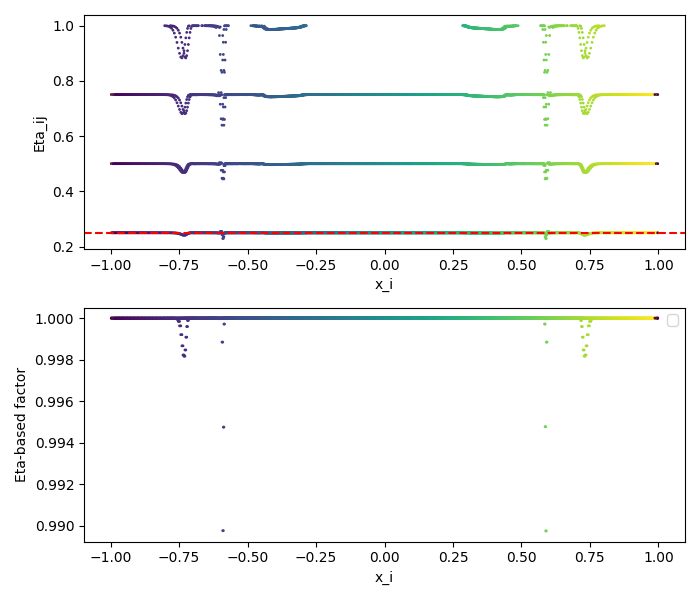

In [17]:
eta_crit = 1/4
eta_fold = 0.2

eta_i = x_ij[:, 0] / currentState.supports[adjacency.i] * 2
eta_j = x_ij[:, 0] / currentState.supports[adjacency.j] * 2

eta_i_norm = torch.abs(eta_i)
eta_j_norm = torch.abs(eta_j)
eta_ij = torch.min(eta_i_norm, eta_j_norm)

ramp = torch.exp(- ((eta_ij - eta_crit)/eta_fold)**(2.0))

factor = torch.where(eta_ij > eta_crit, 1.0, ramp)

print(f' Factor shape: {factor.shape}, min: {factor[~torch.isnan(factor)].min().item()}, max: {factor[~torch.isnan(factor)].max().item()}, mean: {factor.nanmean().item()}, nans: {torch.isnan(factor).sum().item()}/{factor.numel()}, inf values: {(torch.isinf(factor).sum().item())}')

fig, axis = plt.subplots(2,1, figsize = (7, 6), squeeze = False)

axis[0,0].scatter(x_i[adjacency.i != adjacency.j].cpu(), eta_ij[adjacency.i != adjacency.j].cpu(), s = 1, c = x_j[adjacency.i != adjacency.j].cpu())
axis[0,0].set_xlabel('x_i')
axis[0,0].set_ylabel('Eta_ij')
axis[0,0].axhline(eta_crit, color = 'red', linestyle = '--', label = 'Eta crit')

axis[1,0].scatter(x_i[adjacency.i != adjacency.j].cpu(), factor[adjacency.i != adjacency.j].cpu(), s = 1, c = x_j[adjacency.i != adjacency.j].cpu())
axis[1,0].set_xlabel('x_i')
axis[1,0].set_ylabel('Eta-based factor')
axis[1,0].legend()

fig.tight_layout()

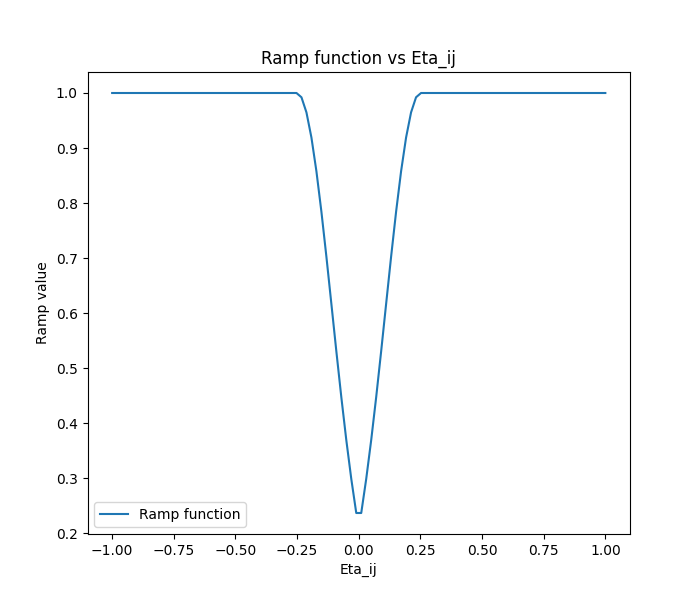

In [18]:
fig, axis = plt.subplots(1,1, figsize = (7, 6), squeeze = False)
xx = torch.linspace(-1, 1, 100)
eta_ij = torch.abs(xx)
ramp = torch.exp(- ((eta_ij - eta_crit)/eta_fold)**(2.0))
factor = torch.where(xx.abs() > eta_crit, 1.0, ramp)
axis[0,0].plot(xx.cpu(), factor.cpu(), label = 'Ramp function')
axis[0,0].set_xlabel('Eta_ij')
axis[0,0].set_ylabel('Ramp value')
axis[0,0].set_title('Ramp function vs Eta_ij')
axis[0,0].legend()